# 실험 02: LangGraph 기본 - 반성 루프 (Reflection)

## 1. 실험 제목과 목표
- **제목**: 자기 자신을 채찍질하는 봇
- **목표**: 교안 15번 슬라이드의 두 번째 패턴인 **Reflection / Evaluator-Optimizer** 패턴을 구현합니다. 초안을 작성하는 노드와 이를 평가하는 노드를 분리하여, 합격점이 나올 때까지 무한 반복하며 답변의 품질을 끌어올리는 구조를 배웁니다.

## 2. 라이브러리 import

In [1]:
import os
from dotenv import load_dotenv
from typing import TypedDict, List

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langgraph.graph import StateGraph, END
from pydantic import BaseModel, Field

## 3. 환경 변수 로드 및 State 정의

In [2]:
load_dotenv()
llm = ChatOpenAI(model="gpt-4o-mini")

# 상태 가방 정의
class ReflectionState(TypedDict):
    topic: str # 사용자가 요청한 글쓰기 주제
    draft: str # 현재까지 작성된 초안
    critique: str # 평가 노드가 뱉어낸 비판 내용
    is_pass: bool # 합격 여부
    revision_count: int # 재작성 횟수 (무한 루프 방지용)

## 4. Node(작성자 & 평가자) 정의
가혹한 평가자와 불쌍한 작성자를 만듭니다.

In [3]:
def node_generator(state: ReflectionState):
    print("\n✍️ [Node: Generator] 글을 작성(또는 수정) 중입니다...")
    topic = state["topic"]
    draft = state.get("draft", "")
    critique = state.get("critique", "")
    count = state.get("revision_count", 0)
    
    if draft == "":
        # 첫 작성일 경우
        sys_msg = SystemMessage(content="당신은 시인입니다. 3줄짜리 짧은 감성적인 시를 지어주세요.")
        user_msg = HumanMessage(content=f"주제: {topic}")
    else:
        # 재작성일 경우 (이전 초안과 비판 내용을 함께 던져줍니다)
        sys_msg = SystemMessage(content="당신은 시인입니다. 편집자의 비판을 수용하여 이전 시를 수정해주세요.")
        user_msg = HumanMessage(content=f"주제: {topic}\n이전 초안: {draft}\n편집자 비판: {critique}\n수정된 시를 3줄로 작성해주세요.")
        
    res = llm.invoke([sys_msg, user_msg])
    
    return {
        "draft": res.content,
        "revision_count": count + 1
    }

def node_evaluator(state: ReflectionState):
    print("\n🧐 [Node: Evaluator] 작성된 글을 날카롭게 평가 중입니다...")
    draft = state["draft"]
    
    class Evaluation(BaseModel):
        is_pass: bool = Field(description="시가 정말 감동적이고 주제를 잘 담고 있으면 true, 아니면 false")
        feedback: str = Field(description="is_pass가 false일 경우, 수정해야 할 부분에 대한 구체적인 비판")

    evaluator_llm = llm.with_structured_output(Evaluation)
    
    sys_msg = SystemMessage(content="당신은 매우 엄격한 문학 편집장입니다. 시에 '별'이나 '달' 같은 진부한 단어가 들어가면 무조건 불합격(false)을 주고 독창성을 요구하세요.")
    user_msg = HumanMessage(content=f"평가할 시:\n{draft}")
    
    eval_result = evaluator_llm.invoke([sys_msg, user_msg])
    
    if eval_result.is_pass:
        print("-> [평가 결과] 합격! 훌륭합니다.")
    else:
        print(f"-> [평가 결과] 불합격! (이유: {eval_result.feedback})")
        
    return {
        "is_pass": eval_result.is_pass,
        "critique": eval_result.feedback
    }

## 5. 그래프 배선 (반성 루프 만들기)

In [4]:
workflow = StateGraph(ReflectionState)

# 노드 추가
workflow.add_node("generator", node_generator)
workflow.add_node("evaluator", node_evaluator)

# 시작점 설정
workflow.set_entry_point("generator")

# 작성자 -> 평가자 (무조건 이동)
workflow.add_edge("generator", "evaluator")

# 평가 결과에 따른 분기 (합격이면 끝, 불합격이면 다시 작성자에게)
def decide_to_finish(state: ReflectionState):
    # 무한 루프 방지 (최대 3번까지만 재작성)
    if state["revision_count"] >= 3:
        print("\n[시스템] 최대 재작성 횟수(3회) 초과로 강제 종료합니다.")
        return "end"
        
    if state["is_pass"]:
        return "end"
    else:
        return "retry"

workflow.add_conditional_edges(
    "evaluator",
    decide_to_finish,
    {
        "end": END,
        "retry": "generator" # 다시 генератор로 보냅니다!
    }
)

app = workflow.compile()

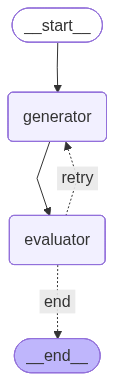

In [5]:
app

## 6. 실험: 자가 발전 테스트
일부러 진부한 단어가 나오기 쉬운 주제를 줘봅시다.

In [6]:
topic = "밤하늘"

print(f"=== 주제: {topic} ===")
# 전체 과정을 실행하고 마지막 상태(State)를 가져옵니다.
final_state = app.invoke({"topic": topic})

print("\n\n✨ [최종 완성본] ✨")
print(final_state["draft"])

=== 주제: 밤하늘 ===

✍️ [Node: Generator] 글을 작성(또는 수정) 중입니다...

🧐 [Node: Evaluator] 작성된 글을 날카롭게 평가 중입니다...
-> [평가 결과] 불합격! (이유: '별빛'과 '아름답게 빛나네'는 너무 진부한 표현입니다. 독창적인 이미지를 찾기 위해 다른 상상력을 발휘해 보세요.)

✍️ [Node: Generator] 글을 작성(또는 수정) 중입니다...

🧐 [Node: Evaluator] 작성된 글을 날카롭게 평가 중입니다...
-> [평가 결과] 불합격! (이유: '밤하늘'이라는 진부한 표현이 사용되었습니다. 더욱 독창적인 이미지를 만들어내는 것이 필요합니다.)

✍️ [Node: Generator] 글을 작성(또는 수정) 중입니다...

🧐 [Node: Evaluator] 작성된 글을 날카롭게 평가 중입니다...
-> [평가 결과] 불합격! (이유: '별빛'이라는 진부한 표현이 사용되었습니다. 더 독창적인 이미지를 통해 감정을 전달할 수 있는 방법을 모색해보세요.)

[시스템] 최대 재작성 횟수(3회) 초과로 강제 종료합니다.


✨ [최종 완성본] ✨
무한한 유리판 위에 떠도는  
별빛의 작은 파편들,  
어둠 속에서 은밀히 교감하네.


## 7. 결과 해석

1. **품질의 비약적 상승**: LLM 하나에게 "처음부터 완벽하게 써줘"라고 하는 것(Zero-shot)보다, "일단 쓰고 비판받고 고쳐"라고 하는 Reflection 구조가 압도적으로 높은 품질의 결과물을 만듭니다.
2. **역할극의 진수**: Generator(시인)와 Evaluator(편집장) 페르소나를 완벽히 분리함으로써, 마치 두 사람의 전문가가 회의실에서 토론하며 글을 다듬는 효과를 시스템으로 구현했습니다.